In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# STEP 1: LOAD REQUIRED LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Best-performing model
from xgboost import XGBRegressor

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)

print("Deployment libraries loaded successfully.")

Deployment libraries loaded successfully.


In [ ]:
# STEP 2: LOAD THE FINAL PHASE 3 DATASET

df = pd.read_csv('/content/drive/MyDrive/Dissertation Dataset/walmart_phase3_final.csv')

# Ensure Date is datetime
df['Date'] = pd.to_datetime(df['Date'])

# Keep proper ordering for consistency
df = df.sort_values(['Store', 'Date']).reset_index(drop=True)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)
print(df.head())

Dataset loaded successfully.
Dataset shape: (6255, 15)
   Store       Date  Weekly_Sales  Holiday_Flag  Temperature  Fuel_Price  \
0      1 2010-03-05  1,554,806.68             0        46.50        2.62   
1      1 2010-03-12  1,439,541.59             0        57.79        2.67   
2      1 2010-03-19  1,472,515.79             0        54.58        2.72   
3      1 2010-03-26  1,404,429.92             0        51.45        2.73   
4      1 2010-04-02  1,594,968.28             0        62.27        2.72   

     CPI  Unemployment        lag_1        lag_4  Month  Week  rolling_mean_4  \
0 211.35          8.11 1,409,727.59 1,643,690.90      3     9    1,554,614.97   
1 211.38          8.11 1,554,806.68 1,641,957.44      3    10    1,504,011.01   
2 211.22          8.11 1,439,541.59 1,611,968.17      3    11    1,469,147.91   
3 211.02          8.11 1,472,515.79 1,409,727.59      3    12    1,467,823.50   
4 210.82          7.81 1,404,429.92 1,554,806.68      4    13    1,477,863.90   

 

In [ ]:
# STEP 3: DEFINE FINAL FEATURES AND TARGET

features = [
    'Store',
    'Holiday_Flag',
    'Temperature',
    'Fuel_Price',
    'CPI',
    'Unemployment',
    'lag_1',
    'lag_4',
    'rolling_mean_4',
    'rolling_std_4',
    'Year',
    'Month',
    'Week'
]

target = 'Weekly_Sales'

In [ ]:
# STEP 4: RECREATE THE SAME CORRECTED TIME-BASED SPLIT

# Sort by Date and Store for stable chronological order
df = df.sort_values(['Date', 'Store']).reset_index(drop=True)

# Use unique dates for an 80/20 chronological split
unique_dates = sorted(df['Date'].unique())
split_index = int(len(unique_dates) * 0.8)
split_date = unique_dates[split_index]

train = df[df['Date'] < split_date].copy()
test = df[df['Date'] >= split_date].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Split date:", split_date)
print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Training date range:", train['Date'].min(), "to", train['Date'].max())
print("Testing date range:", test['Date'].min(), "to", test['Date'].max())

Split date: 2012-04-20 00:00:00
Training observations: 4995
Testing observations: 1260
Training date range: 2010-03-05 00:00:00 to 2012-04-13 00:00:00
Testing date range: 2012-04-20 00:00:00 to 2012-10-26 00:00:00


In [ ]:
# STEP 5: TRAIN THE DEPLOYMENT MODEL (XGBOOST)

xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb_model.fit(X_train, y_train)

print("Deployment model trained successfully.")

Deployment model trained successfully.


In [ ]:
# STEP 6: GENERATE OPERATIONAL FORECAST OUTPUTS

test_deploy = test.copy()
test_deploy['Predicted_Weekly_Sales'] = xgb_model.predict(X_test)
test_deploy['Forecast_Error'] = test_deploy['Weekly_Sales'] - test_deploy['Predicted_Weekly_Sales']
test_deploy['Absolute_Error'] = np.abs(test_deploy['Forecast_Error'])

print(test_deploy[['Date', 'Store', 'Weekly_Sales', 'Predicted_Weekly_Sales', 'Forecast_Error']].head())

           Date  Store  Weekly_Sales  Predicted_Weekly_Sales  Forecast_Error
4995 2012-04-20      1  1,521,577.87            1,724,581.25     -203,003.38
4996 2012-04-20      2  1,847,344.45            1,983,087.00     -135,742.55
4997 2012-04-20      3    434,822.13              440,717.69       -5,895.56
4998 2012-04-20      4  2,144,336.89            2,270,955.75     -126,618.86
4999 2012-04-20      5    330,063.06              372,912.97      -42,849.91


In [ ]:
# STEP 7: CREATE WEEKLY AGGREGATED PROTOTYPE FORECAST TABLE

prototype_forecast = test_deploy.groupby('Date', as_index=False).agg(
    Actual_Weekly_Sales=('Weekly_Sales', 'sum'),
    Predicted_Weekly_Sales=('Predicted_Weekly_Sales', 'sum'),
    Mean_Absolute_Error=('Absolute_Error', 'mean')
)

prototype_forecast['Forecast_Difference'] = (
    prototype_forecast['Actual_Weekly_Sales'] - prototype_forecast['Predicted_Weekly_Sales']
)

print(prototype_forecast.head())

        Date  Actual_Weekly_Sales  Predicted_Weekly_Sales  \
0 2012-04-20        45,072,529.78           49,164,632.00   
1 2012-04-27        43,716,798.89           46,518,112.00   
2 2012-05-04        47,124,197.93           46,516,300.00   
3 2012-05-11        46,925,878.99           45,402,660.00   
4 2012-05-18        46,823,939.22           45,253,252.00   

   Mean_Absolute_Error  Forecast_Difference  
0            96,062.08        -4,092,102.22  
1            63,699.71        -2,801,313.11  
2            26,171.59           607,897.93  
3            39,926.42         1,523,218.99  
4            35,653.84         1,570,687.22  


In [ ]:
# STEP 8: CREATE DEMAND-LEVEL CLASSIFICATION FOR DECISION SUPPORT

# Use tercile-style cut points based on predicted weekly totals
q1 = prototype_forecast['Predicted_Weekly_Sales'].quantile(0.33)
q2 = prototype_forecast['Predicted_Weekly_Sales'].quantile(0.66)

def classify_demand(x):
    if x <= q1:
        return 'Low Demand'
    elif x <= q2:
        return 'Moderate Demand'
    else:
        return 'High Demand'

prototype_forecast['Demand_Level'] = prototype_forecast['Predicted_Weekly_Sales'].apply(classify_demand)

print(prototype_forecast[['Date', 'Predicted_Weekly_Sales', 'Demand_Level']].head(10))

        Date  Predicted_Weekly_Sales     Demand_Level
0 2012-04-20           49,164,632.00      High Demand
1 2012-04-27           46,518,112.00  Moderate Demand
2 2012-05-04           46,516,300.00  Moderate Demand
3 2012-05-11           45,402,660.00       Low Demand
4 2012-05-18           45,253,252.00       Low Demand
5 2012-05-25           47,363,140.00  Moderate Demand
6 2012-06-01           48,987,624.00      High Demand
7 2012-06-08           48,383,164.00      High Demand
8 2012-06-15           48,464,764.00      High Demand
9 2012-06-22           47,926,672.00      High Demand


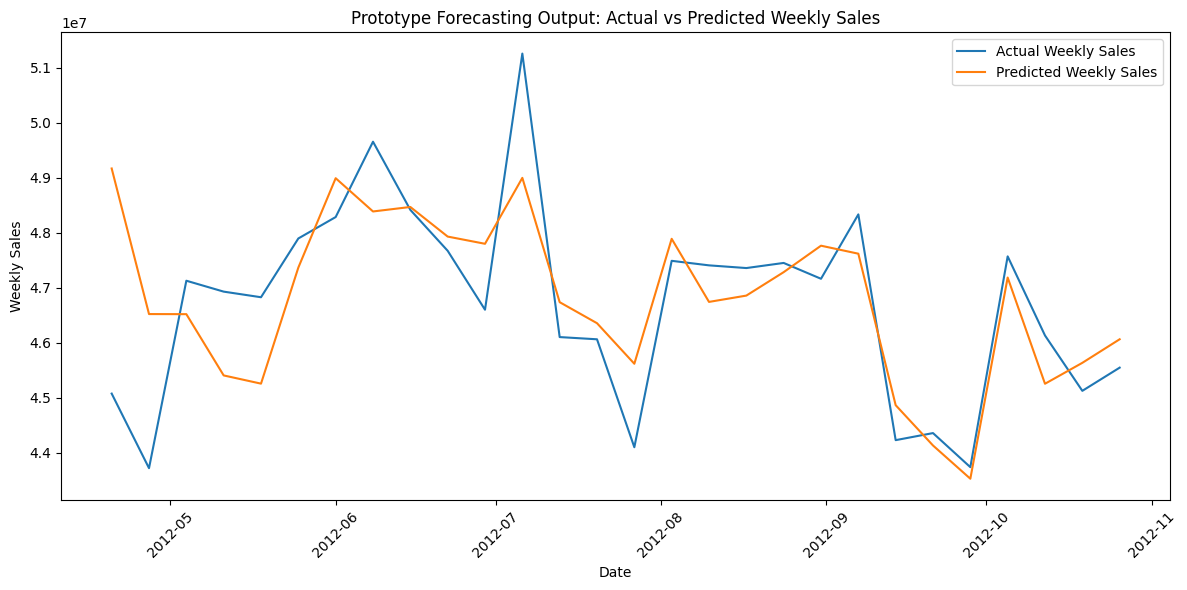

In [ ]:
# STEP 9: CREATE PROTOTYPE FORECAST DASHBOARD CHART

plt.figure(figsize=(12, 6))
plt.plot(prototype_forecast['Date'], prototype_forecast['Actual_Weekly_Sales'], label='Actual Weekly Sales')
plt.plot(prototype_forecast['Date'], prototype_forecast['Predicted_Weekly_Sales'], label='Predicted Weekly Sales')
plt.title('Prototype Forecasting Output: Actual vs Predicted Weekly Sales')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

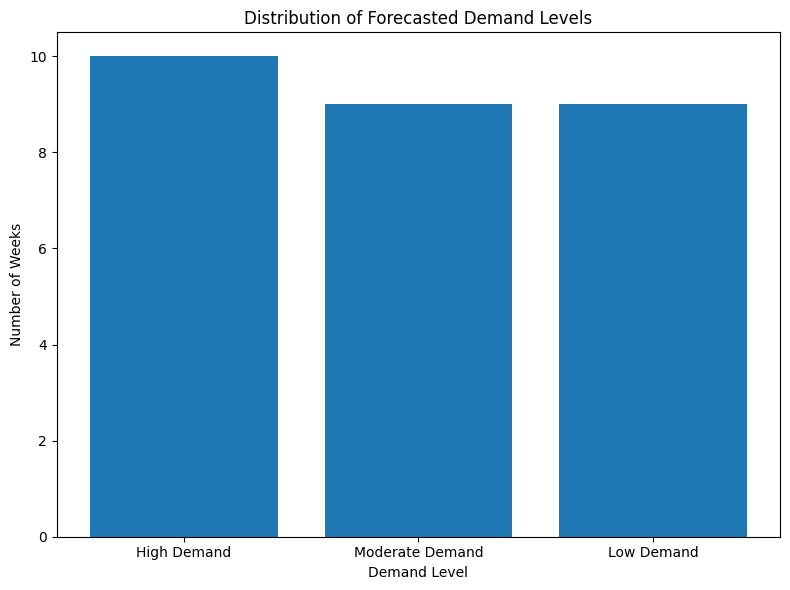

In [ ]:
# STEP 10: CREATE OPERATIONAL DEMAND-LEVEL CHART

demand_counts = prototype_forecast['Demand_Level'].value_counts()

plt.figure(figsize=(8, 6))
plt.bar(demand_counts.index, demand_counts.values)
plt.title('Distribution of Forecasted Demand Levels')
plt.xlabel('Demand Level')
plt.ylabel('Number of Weeks')
plt.tight_layout()
plt.show()

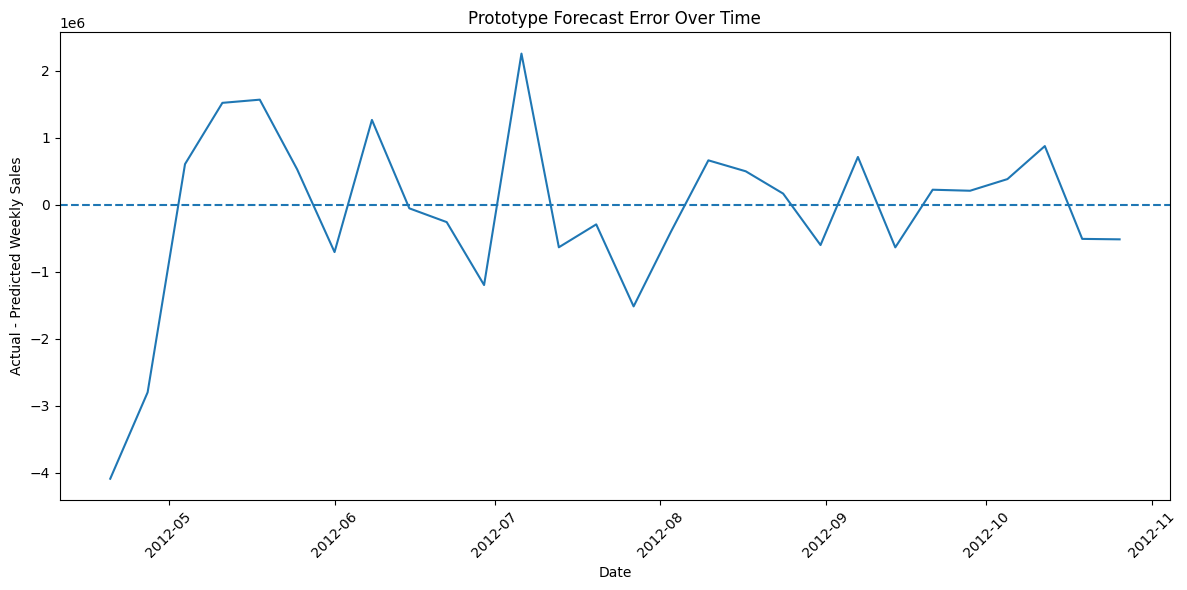

In [ ]:
# STEP 11: FORECAST ERROR MONITORING CHART

plt.figure(figsize=(12, 6))
plt.plot(prototype_forecast['Date'], prototype_forecast['Forecast_Difference'])
plt.axhline(0, linestyle='--')
plt.title('Prototype Forecast Error Over Time')
plt.xlabel('Date')
plt.ylabel('Actual - Predicted Weekly Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# STEP 12: CREATE PROTOTYPE SUMMARY TABLE

prototype_summary = pd.DataFrame({
    'Metric': [
        'Number of forecast weeks',
        'Average predicted weekly sales',
        'Average actual weekly sales',
        'Average forecast difference',
        'Maximum predicted weekly sales',
        'Minimum predicted weekly sales'
    ],
    'Value': [
        len(prototype_forecast),
        prototype_forecast['Predicted_Weekly_Sales'].mean(),
        prototype_forecast['Actual_Weekly_Sales'].mean(),
        prototype_forecast['Forecast_Difference'].mean(),
        prototype_forecast['Predicted_Weekly_Sales'].max(),
        prototype_forecast['Predicted_Weekly_Sales'].min()
    ]
})

print(prototype_summary)

                           Metric         Value
0        Number of forecast weeks         28.00
1  Average predicted weekly sales 46,794,536.00
2     Average actual weekly sales 46,697,627.87
3     Average forecast difference    -96,902.56
4  Maximum predicted weekly sales 49,164,632.00
5  Minimum predicted weekly sales 43,524,744.00


In [ ]:
# STEP 13: GENERATE A PRACTICAL STORE-LEVEL DEPLOYMENT OUTPUT

store_forecast_summary = test_deploy.groupby('Store', as_index=False).agg(
    Actual_Sales=('Weekly_Sales', 'sum'),
    Predicted_Sales=('Predicted_Weekly_Sales', 'sum'),
    Mean_Absolute_Error=('Absolute_Error', 'mean')
)

store_forecast_summary['Difference'] = (
    store_forecast_summary['Actual_Sales'] - store_forecast_summary['Predicted_Sales']
)

print(store_forecast_summary.head(10))

   Store  Actual_Sales  Predicted_Sales  Mean_Absolute_Error  Difference
0      1 43,957,586.61    43,970,108.00            54,460.61  -12,521.39
1      2 52,903,569.66    52,968,448.00            42,372.15  -64,878.34
2      3 11,678,607.91    11,539,274.00            10,413.51  139,333.91
3      4 60,265,371.42    60,768,996.00            47,776.81 -503,624.58
4      5  9,176,639.57     9,324,438.00            11,705.32 -147,798.43
5      6 43,390,581.40    43,606,484.00            44,098.68 -215,902.60
6      7 16,436,063.05    16,535,445.00            27,330.46  -99,381.95
7      8 25,407,706.81    25,154,948.00            21,980.14  252,758.81
8      9 15,507,619.87    15,674,288.00            17,851.06 -166,668.13
9     10 49,601,600.61    50,252,548.00            48,771.75 -650,947.39


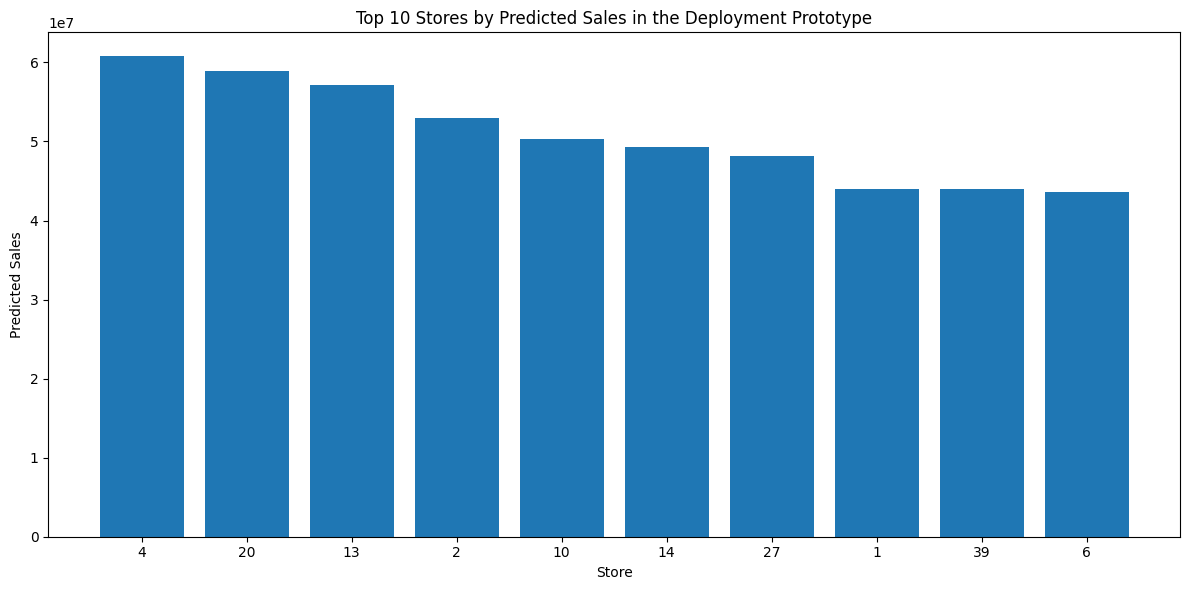

In [ ]:
# STEP 14: STORE-LEVEL FORECAST COMPARISON CHART

top_stores = store_forecast_summary.sort_values('Predicted_Sales', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_stores['Store'].astype(str), top_stores['Predicted_Sales'])
plt.title('Top 10 Stores by Predicted Sales in the Deployment Prototype')
plt.xlabel('Store')
plt.ylabel('Predicted Sales')
plt.tight_layout()
plt.show()

In [ ]:
# STEP 15: EXPORT PROTOTYPE OUTPUTS FOR DISSERTATION TABLES

prototype_forecast.to_csv('/content/prototype_forecast_output.csv', index=False)
prototype_summary.to_csv('/content/prototype_summary.csv', index=False)
store_forecast_summary.to_csv('/content/store_forecast_summary.csv', index=False)

print("Prototype deployment outputs exported successfully.")

Prototype deployment outputs exported successfully.
